# Perceptron — Assignment Notebook

For this assignment, we will be implementing a Perceptron model using different approaches, analyzing their results. 

## Approaches
### Approach 1: Heuristic Approach
### Approach 2: Gradient Descent Approach

## Setup

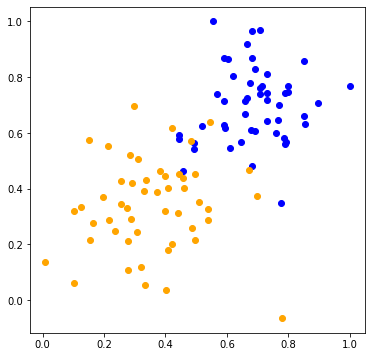

In [1]:
import math
import random
from dataclasses import dataclass
from typing import List, Tuple

import matplotlib.pyplot as plt

# Import data.
# If pandas not installed, uncomment as needed:
#!pip -q install pandas
import numpy as np
import pandas as pd
data_file = pd.read_csv("data-1.csv", header=None)
p_data = data_file[[0,1,2]].values

# Make a plot to show data.
plt.figure(figsize=(6, 6))
# Scatter Plot
plt.scatter(p_data[:, 0][p_data[:, 2] == 0], p_data[:, 1][p_data[:, 2] == 0], color='blue', label='Type 0')
plt.scatter(p_data[:, 0][p_data[:, 2] == 1], p_data[:, 1][p_data[:, 2] == 1], color='orange', label='Type 1')
# Show
plt.show()

# Set learning rate to be used.
learning_rate = 0.01
epoch_count = 1000

## Approach 1: Heuristic Approach

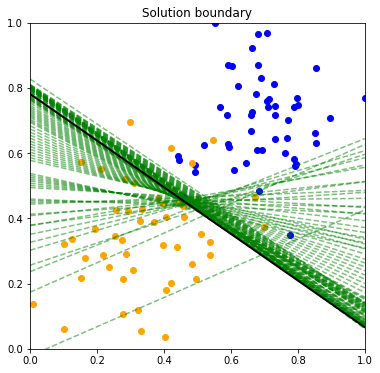

In [2]:
# Plot setup.
plt.figure(figsize=(6, 6))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Solution boundary")
# Scatter Plot
plt.scatter(p_data[:, 0][p_data[:, 2] == 0], p_data[:, 1][p_data[:, 2] == 0], color='blue', label='Type 0')
plt.scatter(p_data[:, 0][p_data[:, 2] == 1], p_data[:, 1][p_data[:, 2] == 1], color='orange', label='Type 1')

weights = np.random.randn(2)
bias = np.random.randn()

result_history = []

for i in range(epoch_count):
    result_history.append((weights.copy(), bias))
    for x in range(len(p_data)):
        x_0 = p_data[x][0]
        x_1 = p_data[x][1]
        y_true = p_data[x][2]
        
        y_hat = 1 if weights[0] * x_0 + weights[1] * x_1 + bias >= 0 else 0
        
        if y_hat != y_true:
            if y_hat == 0:
                bias = bias + learning_rate
                weights[0] = weights[0] + (learning_rate * x_0)
                weights[1] = weights[1] + (learning_rate * x_1)
            else:
                bias = bias - learning_rate
                weights[0] = weights[0] - (learning_rate * x_0)
                weights[1] = weights[1] - (learning_rate * x_1)
    # Print results
    #print(weights, " ", bias)

result_history.append((weights.copy(), bias))

# Plot lines
x_vals = np.linspace(0, 1, 100)
# Initial (red)
w, b = result_history[0]
y_vals = (-w[0] * x_vals - b) / w[1]
plt.plot(x_vals, y_vals, color='red')
# Progression (green)
for w, b in result_history[1:-1]:
    y_vals = (-w[0] * x_vals - b) / w[1]
    plt.plot(x_vals, y_vals, 'g--', alpha=0.5)
#Final (black)
w, b = result_history[-1]
y_vals = (-w[0] * x_vals - b) / w[1]
plt.plot(x_vals, y_vals, color='black', linewidth=2)

plt.show()

## Approach 2: Gradient Descent Approach

0.7723257482218903
0.6981422540845663
0.6617398087648866
0.6430645135064051
0.6319331031429938
0.6237882467598294
0.6167331189927517
0.6100306690816282
0.6034258130942496
0.5968535862842136
0.5903172878216097
0.5838395515028472
0.5774440879822142
0.571149948750827
0.5649706151083724
0.5589147227122438
0.5529871597823889
0.5471900864034285
0.5415237497112017
0.5359870923171685
0.5305781895282016
0.5252945564474647
0.5201333605212856
0.5150915671347758
0.5101660385429687
0.505353600595393
0.5006510873691096
0.49605537070624195
0.4915633794605001
0.48717211173795183
0.4828786423730634
0.4786801271670062
0.47457380492863366
0.47055699802740875
0.46662711194247064
0.46278163413893075
0.4590181324983197
0.45533425345911427
0.45172771997482647
0.4481963293639455
0.44473795110329
0.4413505246006195
0.43803205697153
0.43478062083808877
0.43159435216139835
0.4284714481165461
0.4254101650157706
0.42240881628374866
0.41946577048757455
0.416579449422959
0.4137483262574633
0.41097092373101485
0.4082

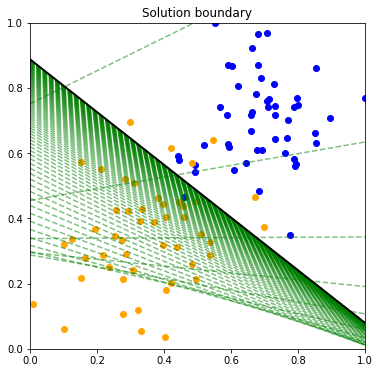

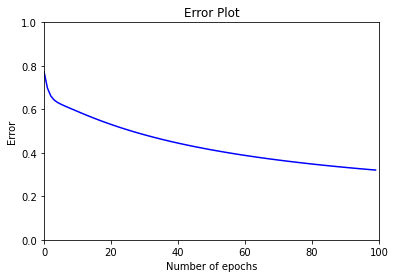

In [3]:
# Plot setup.
plt.figure(figsize=(6, 6))
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.title("Solution boundary")
# Scatter Plot
plt.scatter(p_data[:, 0][p_data[:, 2] == 0], p_data[:, 1][p_data[:, 2] == 0], color='blue', label='Type 0')
plt.scatter(p_data[:, 0][p_data[:, 2] == 1], p_data[:, 1][p_data[:, 2] == 1], color='orange', label='Type 1')

weights = np.random.randn(2)
bias = np.random.randn()

result_history = []
loss_history = []

for i in range(epoch_count):
    result_history.append((weights.copy(), bias))
    loss = 0.0
    for x in range(len(p_data)):
        x_0 = p_data[x][0]
        x_1 = p_data[x][1]
        y_true = p_data[x][2]
        
        z = weights[0] * x_0 + weights[1] * x_1 + bias
        y_hat = 1 / (1 + np.exp(-z))
        
        loss = loss-(y_true * np.log(y_hat) + (1 - y_true) * np.log(1 - y_hat))
        
        y_error = y_true - y_hat
        bias = bias + (learning_rate * y_error)
        weights[0] = weights[0] + (learning_rate * y_error * x_0)
        weights[1] = weights[1] + (learning_rate * y_error * x_1)
    
    total_loss = loss / len(p_data)
    # Print results
    #print(weights, " ", bias)
    print(total_loss)
    loss_history.append(total_loss)
    
    # If loss is small, break.
    if total_loss < .15:
        break
    
result_history.append((weights.copy(), bias))

    
# Plot lines
x_vals = np.linspace(0, 1, 100)
# Initial (red)
w, b = result_history[0]
y_vals = (-w[0] * x_vals - b) / w[1]
plt.plot(x_vals, y_vals, color='red')
# Progression (green)
for w, b in result_history[1:-1]:
    y_vals = (-w[0] * x_vals - b) / w[1]
    plt.plot(x_vals, y_vals, 'g--', alpha=0.5)
#Final (black)
w, b = result_history[-1]
y_vals = (-w[0] * x_vals - b) / w[1]
plt.plot(x_vals, y_vals, color='black', linewidth=2)

plt.show()


# Plot loss history.
plt.figure(figsize=(6, 4))
plt.xlim(0, epoch_count)
plt.ylim(0, 1)
plt.plot(range(len(loss_history)), loss_history, color='blue')

plt.title("Error Plot")
plt.xlabel("Number of epochs")
plt.ylabel("Error")

plt.show()